In [1]:
import numpy as np
from scipy.constants import m_p
import tqdm
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
import sys
sys.path.append('../../sedov_theory/python/')
from sedov_theory import SedovTalorProblem
from analysis_tool import CastroSimulation

# Extract initial conditions from BELLA data 

## Extract the deposited energy by fitting Sedov-Taylor theory

In [2]:
t = np.genfromtxt('./ExpansionData/time_list.csv') * 1.e-9 # Convert from ns to s
rn = np.genfromtxt('./ExpansionData/neutral_peak_location_list.csv') * 1.e2 # Convert from m to cm

# Calculate analytical solution
gamma = 5./3
rho = 1.25e18 * (m_p*1.e3) # g / cm^3

E = 300 # erg / cm
sol = SedovTalorProblem(gamma, E, rho)

In [3]:
rho

2.0907774046125e-06

Text(0, 0.5, 't (ns)')

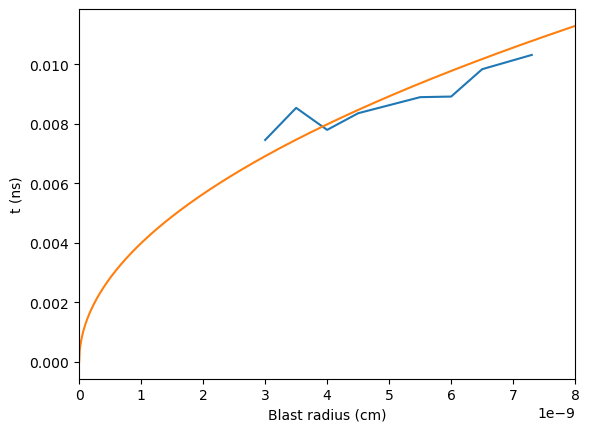

In [4]:
plt.plot( t, rn )
plt.xlim(0, 8e-9)
t0 = np.linspace(0,8e-9,1000)
plt.plot( t0, sol.blast_radius(t0) )
plt.xlabel('Blast radius (cm)')
plt.ylabel('t (ns)')

## Extract initial radius from density plot

In [5]:
r = np.genfromtxt('./RecoveredPhaseAndRetrievedDensities/recovered_x_time_delay_0_ns.csv')
ne = np.genfromtxt('./RecoveredPhaseAndRetrievedDensities/recovered_inverted_ne_time_delay_0_ns.csv')

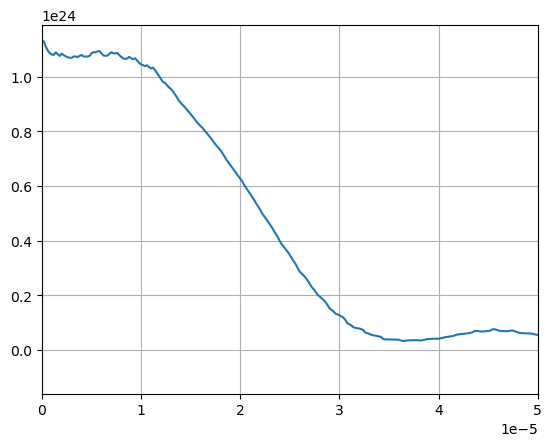

In [6]:
plt.plot(r, ne)
plt.xlim(0, 50e-6)
plt.grid()

# Analyze results of Castro simulation

In [7]:
cs = CastroSimulation('../run/', 'plt_')

100%|█████████████████████████████████████████| 103/103 [00:01<00:00, 85.07it/s]


In [8]:
# Extract data from different time 
# Note that time is not regularly spaced
q_arr = []
rmax_arr = []
for time in tqdm.tqdm( cs.output_times ):
    r, q, t = cs.extract_data(time, 'density', level=2)
    rmax = r[np.argmax(q)]
    rmax_arr.append(rmax)
    q_arr.append(q)
q_arr = np.stack(q_arr)
t_arr = cs.output_times.copy()
r_arr = r

# Interpolate on a grid with regularly-spaced time
interp = RegularGridInterpolator(points=(t_arr, r_arr), values=q_arr, bounds_error=False, fill_value=None)
t_interp, r_interp = np.meshgrid(
    np.linspace(0, t_arr.max(), 1000), 
    np.linspace(0, r_arr.max(), 1000), indexing='ij')
q_interp = interp((t_interp, r_interp))

100%|█████████████████████████████████████████| 103/103 [00:08<00:00, 11.91it/s]


ValueError: x and y must have same first dimension, but have shapes (1,) and (14,)

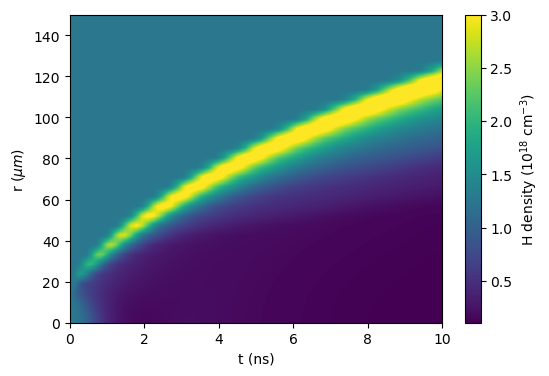

In [9]:
plt.figure(figsize=(6, 4))
plt.imshow(q_interp.T/1.67e-6, origin='lower', 
           extent=[0, t_arr.max()*1.e9, 0, r_arr.max()*1.e4], 
           aspect='auto', vmax=3)
cb = plt.colorbar()
cb.set_label('H density (10$^{18}$ cm$^{-3}$)')
#plt.plot(t_arr, rmax_arr, 'r-')
r_analytical = sol.blast_radius(t_arr)
#plt.plot(t_arr*1.e9, r_analytical*1.e4, 'r--', label='Sedov-Taylor theory')
#plt.legend(loc=0)
plt.ylabel('r ($\mu m$)')
plt.xlabel('t (ns)')
plt.ylim(0,150)
plt.plot( t*1.e9, rn*1e4, 'r-o' )